In [5]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [64]:
df= pd.read_csv("churn_data.csv")
df.head()

,customer_id,age,gender,tenure_months,contract_type,payment_method,has_internet,monthly_charges,total_charges,churn
0,CUST1001,38.0,F,6.0,NaN,Credit card,yes,NaN,NaN,Yes
1,CUST1002,23.0,F,8.0,Month-to-month,credit card,no,-15.00,NaN,No
2,CUST1003,130.0,male,NaN,NaN,Mailed check,Yes,117.63,NaN,No
3,CUST1004,36.0,Female,69.0,NaN,Electronic check,Y,101.61,7011.09,No
4,CUST1005,130.0,Female,47.0,NaN,e-check,Yes,-15.00,NaN,No


In [65]:
df=df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [70]:
# df = df.replace(r'^\s*$', np.nan, regex=True)
df["total_charges"]=df["total_charges"].astype(float)
df.dtypes

customer_id            str
age                float64
gender                 str
tenure_months      float64
contract_type          str
payment_method         str
has_internet           str
monthly_charges    float64
total_charges      float64
churn                  str
dtype: object

In [78]:
df["total_charges"]=df["total_charges"].fillna(df["total_charges"].mean())
df["age"]=df["age"].fillna(df["age"].median())
df["gender"]=df["gender"].fillna("unknown")
df["contract_type"]=df["contract_type"].fillna(df["contract_type"].mode()[0])
df["tenure_months"]=df["tenure_months"].fillna(df["tenure_months"].mode()[0])
df["payment_method"]=df["payment_method"].fillna(df["payment_method"].mode()[0])
df["has_internet"]=df["has_internet"].fillna(df["has_internet"].mode()[0])
df.loc[df["monthly_charges"]<0,"monthly_charges"]=np.nan
df["monthly_charges"]=df["monthly_charges"].fillna(df["monthly_charges"].mean())

In [79]:
df.isnull().sum()


customer_id        0
age                0
gender             0
tenure_months      0
contract_type      0
payment_method     0
has_internet       0
monthly_charges    0
total_charges      0
churn              0
dtype: int64

In [80]:
df.head()

,customer_id,age,gender,tenure_months,contract_type,payment_method,has_internet,monthly_charges,total_charges,churn
0,CUST1001,38.0,F,6.0,month-to-month,Credit card,yes,71.163704,2812.911493,Yes
1,CUST1002,23.0,F,8.0,Month-to-month,credit card,no,71.163704,2812.911493,No
2,CUST1003,130.0,male,57.0,month-to-month,Mailed check,Yes,117.630000,2812.911493,No
3,CUST1004,36.0,Female,69.0,month-to-month,Electronic check,Y,101.610000,7011.090000,No
4,CUST1005,130.0,Female,47.0,month-to-month,e-check,Yes,71.163704,2812.911493,No


In [86]:
df["gender"]=df["gender"].replace({"F":"Female",
                      "M":"Male",
                      "male":"Male"})

In [87]:
df["gender"].unique()

<StringArray>
['Female', 'Male', 'unknown']
Length: 3, dtype: str

In [90]:
df["payment_method"].unique()

<StringArray>
[     'Credit card',      'credit card',     'Mailed check',
 'Electronic check',          'e-check',    'Bank transfer']
Length: 6, dtype: str

In [91]:
df["payment_method"]=df["payment_method"].replace({"credit card":"Credit card",
                                                   "e-check":"Electronic check"})

In [92]:
df["payment_method"].unique()

<StringArray>
['Credit card', 'Mailed check', 'Electronic check', 'Bank transfer']
Length: 4, dtype: str

In [93]:
df["contract_type"].unique()

<StringArray>
['month-to-month', 'Month-to-month', 'Two year', 'One year']
Length: 4, dtype: str

In [96]:
df["contract_type"]=df["contract_type"].replace({"month-to-month":"Month-to-Month",
                                                 "Month-to-month":"Month-to-Month"})

In [97]:
df["contract_type"].unique()

<StringArray>
['Month-to-Month', 'Two year', 'One year']
Length: 3, dtype: str

In [98]:
df["has_internet"].unique()

<StringArray>
['yes', 'no', 'Yes', 'Y', 'No', 'N']
Length: 6, dtype: str

In [99]:
df["has_internet"]=df["has_internet"].replace({"N":"No",
                                               "Y":"Yes",
                                               "no":"No",
                                               "yes":"Yes"})

In [100]:
df["has_internet"].unique()

<StringArray>
['Yes', 'No']
Length: 2, dtype: str

In [103]:
df

,customer_id,age,gender,tenure_months,contract_type,payment_method,has_internet,monthly_charges,total_charges,churn
0,CUST1001,38.0,Female,6.0,Month-to-Month,Credit card,Yes,71.163704,2812.911493,Yes
1,CUST1002,23.0,Female,8.0,Month-to-Month,Credit card,No,71.163704,2812.911493,No
2,CUST1003,130.0,Male,57.0,Month-to-Month,Mailed check,Yes,117.630000,2812.911493,No
3,CUST1004,36.0,Female,69.0,Month-to-Month,Electronic check,Yes,101.610000,7011.090000,No
4,CUST1005,130.0,Female,47.0,Month-to-Month,Electronic check,Yes,71.163704,2812.911493,No
...,...,...,...,...,...,...,...,...,...,...
115,CUST1116,74.0,Male,21.0,Month-to-Month,Electronic check,Yes,81.040000,1701.840000,Yes
116,CUST1117,5.0,Male,58.0,Two year,Credit card,No,40.830000,2368.140000,Yes
117,CUST1118,41.0,Female,23.0,One year,Electronic check,Yes,87.970000,2023.310000,Yes
118,CUST1119,46.0,Male,46.0,Month-to-Month,Credit card,Yes,88.870000,4088.020000,No


In [106]:
df.to_csv("cleaned1_data.csv",index="False")

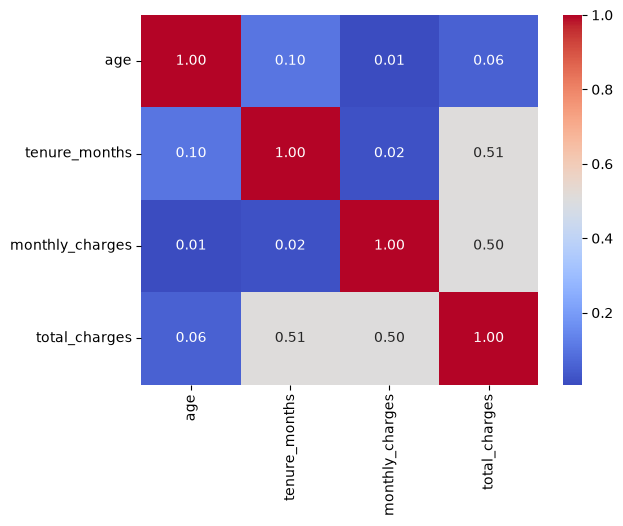

In [115]:
numeric=df.select_dtypes(include=["number"])
plt.Figure(figsize=(10,6))
sns.heatmap(numeric.corr(),annot=True,cmap="coolwarm",fmt=".2f")
plt.show()

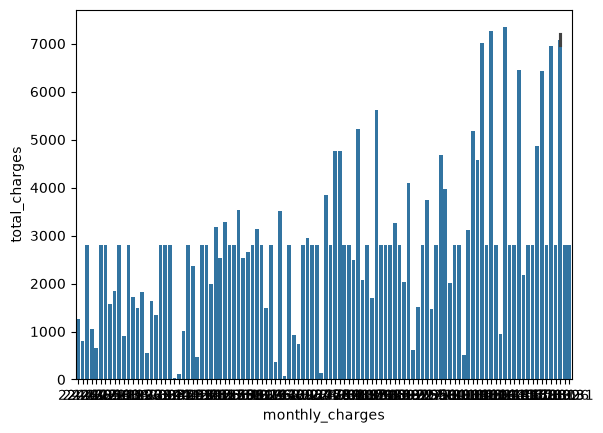

In [122]:
plt.Figure(figsize=(25,12))
sns.barplot(x="monthly_charges",y="total_charges",data=df)
plt.show()